In [1]:
##################### Constant Bathymetry #######################
# Super simple script to load in the grid file, replace the 
# bathymetry profile with a constant value, then save as a 
# new netcdf.
#
# Notes: 
# - 
#
##################################################################

In [5]:
# Load in the modules
import numpy as np
import xarray as xr


In [6]:
# Load in the grid file
og_grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002.nc')

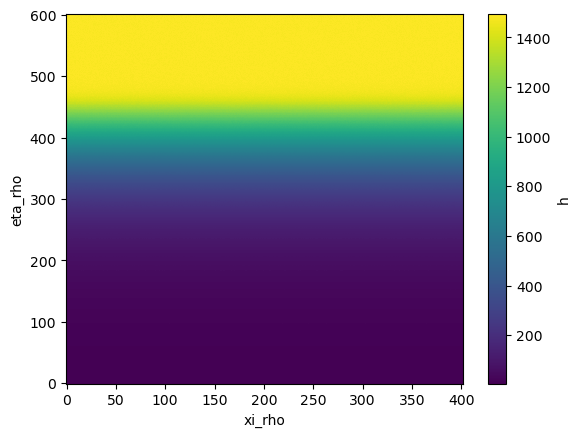

In [7]:
# Plot the original bathymetry
og_grid.h.plot()

In [8]:
# Make a new array that is constant bathymetry but same
# shape as OG
# 20 m constant 
new_const_bathy = np.full_like(og_grid.h, 20.0)

In [14]:
# Make a copy of the grid file
new_grid = og_grid.copy()

In [15]:
new_grid.h

<xarray.DataArray 'h' (eta_rho: 602, xi_rho: 402)> Size: 2MB
array([[   5.013698,    4.996944,    5.01793 , ...,    4.997116,    4.990096,
           5.020922],
       [   5.531654,    5.494657,    5.543554, ...,    5.506051,    5.537651,
           5.521313],
       [   5.940434,    5.941489,    5.974247, ...,    5.975286,    5.934504,
           5.935868],
       ...,
       [1483.484922, 1484.942742, 1488.565652, ..., 1492.997973, 1489.862877,
        1484.756018],
       [1482.111928, 1487.838183, 1494.128785, ..., 1484.634598, 1480.780838,
        1486.501802],
       [1492.794129, 1491.133894, 1488.368446, ..., 1488.753811, 1493.742186,
        1485.175239]])
Dimensions without coordinates: eta_rho, xi_rho

In [16]:
# Set the new bathymetry
new_grid['h'].values = new_const_bathy

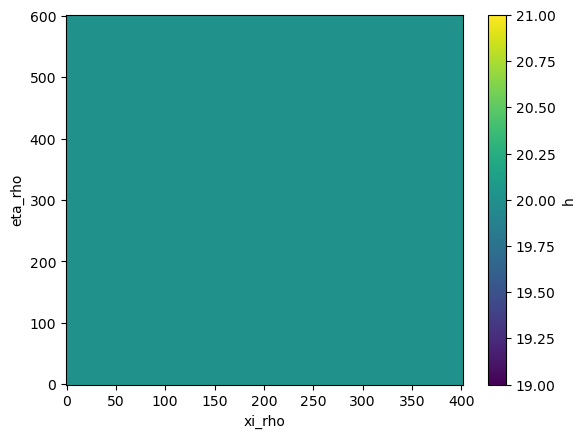

In [17]:
# Plot to see if it worked
new_grid.h.plot()

In [18]:
# Save to a new netCDF
new_grid.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002_constbathy.nc')